In [4]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [5]:
def generate_quantum_random_bits(num_bits):
    """Generates a list of true random bits using quantum superposition."""
    qc = QuantumCircuit(num_bits, num_bits)
    # Apply Hadamard to put qubits in superposition: 1/sqrt(2) (|0> + |1>)
    for i in range(num_bits):
        qc.h(i)
        qc.measure(i, i)

    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    counts = job.result().get_counts(compiled)

    # Extract bitstring, reverse for correct Qiskit indexing, and return as integers
    bitstring = list(counts.keys())[0][::-1]
    return [int(b) for b in bitstring]

--- BB84 Protocol Simulation (Plain) ---
Alice's bits:  [1, 1, 0, 0, 1, 0, 1, 1, 0, 0]
Alice's bases: ['d', 'd', 's', 's', 's', 'd', 's', 's', 'd', 'd']
Bob's bases:   ['s', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 's', 's']
Bob's bits:    [1, 1, 0, 1, 1, 0, 0, 1, 1, 1]
--------------------------------------------------
Match markers: [' ', '|', ' ', ' ', ' ', '|', ' ', ' ', ' ', ' ']
Shared Key:    [1, 0]
Key Length:    2 bits


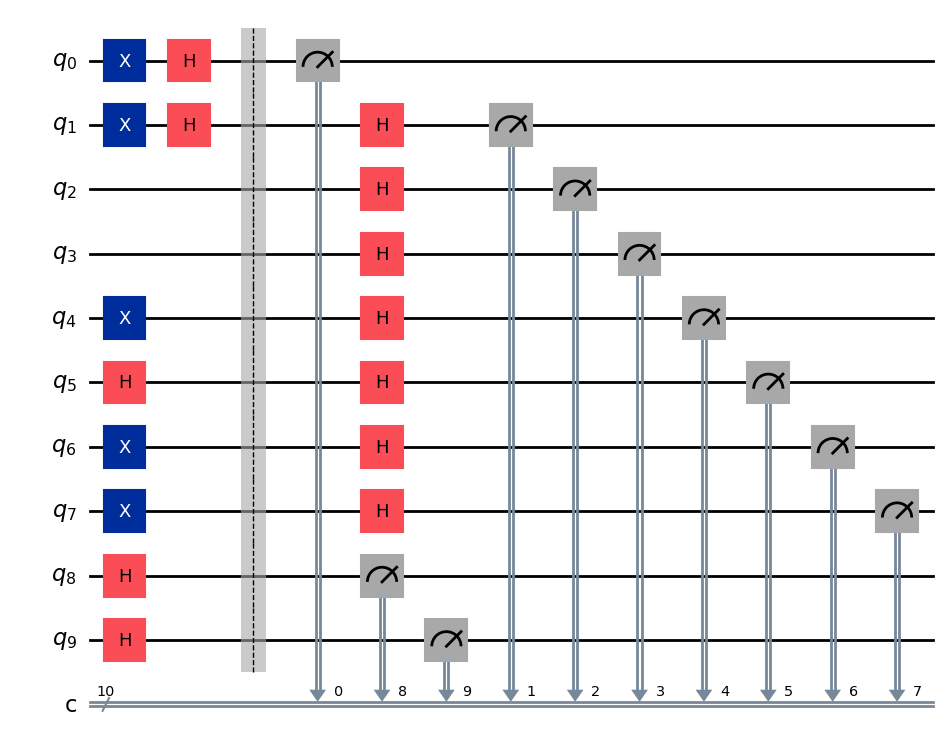

In [6]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.

# Define the number of qubits to send
n = 10

# 1. Alice generates a random sequence of bits (Quantum RNG)
alice_bits = generate_quantum_random_bits(n)

# 2. Alice chooses a random basis for each bit (Quantum RNG)
# We map 0 to 's' (standard) and 1 to 'd' (diagonal)
alice_bases_raw = generate_quantum_random_bits(n)
alice_bases = ['d' if b == 1 else 's' for b in alice_bases_raw]

# 3. Bob chooses a random basis for measuring (Quantum RNG)
bob_bases_raw = generate_quantum_random_bits(n)
bob_bases = ['d' if b == 1 else 's' for b in bob_bases_raw]

# Create a quantum circuit with n qubits and n classical bits
bb84 = QuantumCircuit(n, n)

# 4. Alice prepares her qubits
for i in range(n):
    if alice_bits[i] == 1:
        bb84.x(i)
    if alice_bases[i] == 'd':
        bb84.h(i)

bb84.barrier()

# 5. Bob receives the qubits and measures them
for i in range(n):
    if bob_bases[i] == 'd':
        bb84.h(i)
    bb84.measure(i, i)

# 6. Simulate the communication circuit
backend = BasicSimulator()
compiled = transpile(bb84, backend)
job_sim = backend.run(compiled, shots=1)
counts = job_sim.result().get_counts(compiled)

measured_str = list(counts.keys())[0][::-1]
bob_bits = [int(b) for b in measured_str]

# 7. Sifting: Alice and Bob publicly compare their bases
shared_key = []
for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        shared_key.append(alice_bits[i])

# 8. Output the results
print("--- BB84 Protocol Simulation (Plain) ---")
print(f"Alice's bits:  {alice_bits}")
print(f"Alice's bases: {alice_bases}")
print(f"Bob's bases:   {bob_bases}")
print(f"Bob's bits:    {bob_bits}")
print("-" * 50)
matches = ['|' if alice_bases[i] == bob_bases[i] else ' ' for i in range(n)]
print(f"Match markers: {matches}")
print(f"Shared Key:    {shared_key}")
print(f"Key Length:    {len(shared_key)} bits")


bb84.draw("mpl")